In [204]:
import os
import json
import yaml
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from umap.umap_ import UMAP
import seaborn as sns
from huggingface_hub import login
from datasets import load_dataset, Dataset


In [205]:
def load_personas(hf_persona_path,n_personasample):
    
    print("Using Huggingface Personas")
    print(f"Loading Personas from {hf_persona_path}")
    hf_persona_dataset = load_dataset(hf_persona_path)
    persona_datasets_total = hf_persona_dataset['train']
    total_persona_df = persona_datasets_total.to_pandas()
    persona_datasets = total_persona_df.groupby("archetype").sample(n=n_personasample, random_state=42)
    print(f"No of Personas: {persona_datasets.shape[0]}")
    return persona_datasets

In [18]:
trait_map = {
    "1": "Honesty-Humility",
    "2": "Emotionality",
    "3": "Extraversion",
    "4": "Agreeableness",
    "5": "Conscientiousness",
    "6": "Openness"
}

In [40]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def load_sjt(sjt_dir):
    sjt_list = []
    for file in os.listdir(sjt_dir):
        synthetic_sjt = read_json(os.path.join(sjt_dir, file))
        sjt_list += synthetic_sjt

    print(f"{len(sjt_list)} SJTs Loaded")
    return sjt_list

def get_model_name(filename, file_str):
    model_name = filename.replace("_sjt_answers_","").replace(".json","").replace(file_str,"")
    return model_name

def normalize_sjt_responses(chosen_indices, n_options=6):
    """
    Returns an (n_questions x n_options) matrix where chosen = +1, others = -1.
    chosen_indices is a list or array of 1-indexed chosen options.
    """
    import numpy as np
    chosen_indices = np.array(chosen_indices)
    norm_matrix = -1 * np.ones((len(chosen_indices), n_options), dtype=int)
    norm_matrix[np.arange(len(chosen_indices)), chosen_indices - 1] = 1
    return norm_matrix

In [61]:
def get_true_indices(data):
    resolved_traits = []
    true_answer_indices = []
    for answer, shuffled_indices in zip(data["answers"][0], data['config']['answer_index']):
        # assuming one list per persona
        # shuffled_indices = data["config"]["answer_index"]  # list of per-question shuffles

        # Map answers back to their intended trait meaning
        # resolved_traits = []
        # true_answer_indices = []
        # for ans, shuffle in zip(answer, shuffled_indices):
            # ans is the chosen index (1,2,3,...)
        # shuffle is the shuffled order of indices for this question
        true_index = str(shuffled_indices[int(answer)-1] + 1)  # get original index meaning
        if true_index in trait_map:
            resolved_traits.append(trait_map[true_index])
            true_answer_indices.append(true_index)
    
    return true_answer_indices, resolved_traits

In [63]:
def get_trait_distribution(data):
    
    true_answer_indices, resolved_traits = get_true_indices(data)
    
    trait_counts = Counter(resolved_traits)
    total = sum(trait_counts.values())
    
    trait_summary = {
        trait: {
            "count": trait_counts[trait],
            "proportion": round(trait_counts[trait] / total, 3) if total > 0 else 0
        }
        for index, trait in trait_map.items()
    }
    return [trait_summary[key]['proportion'] for key in trait_summary.keys()]
    

In [3]:
zero_compute_data_dir = "../experiment_results/zero_compute_analysis_sjt/"

huggingface_sjt_answers_gpt-4_1.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:851: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_sjt_answers_Qwen2_5-7B-Instruct.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:851: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_sjt_answers_Llama-3_1-8B-Instruct.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:851: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


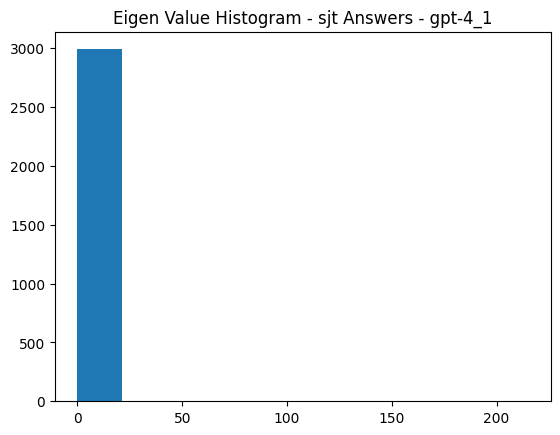

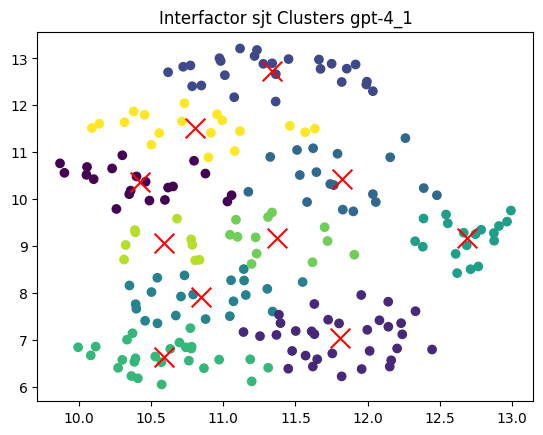

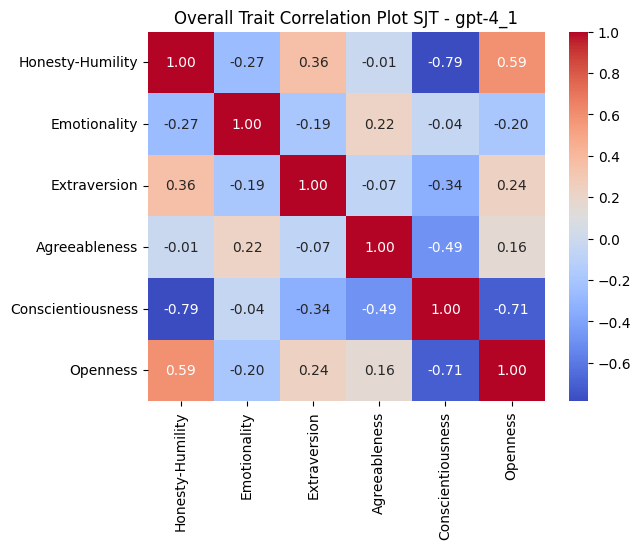

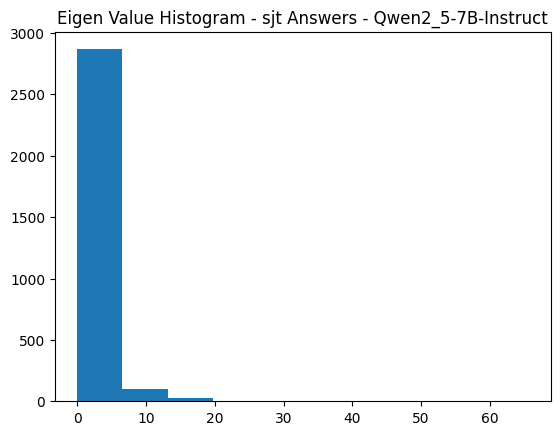

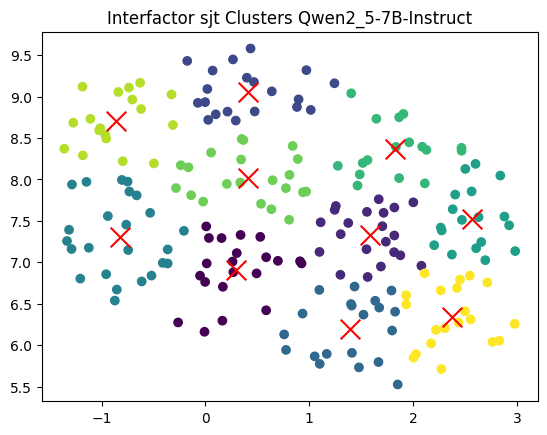

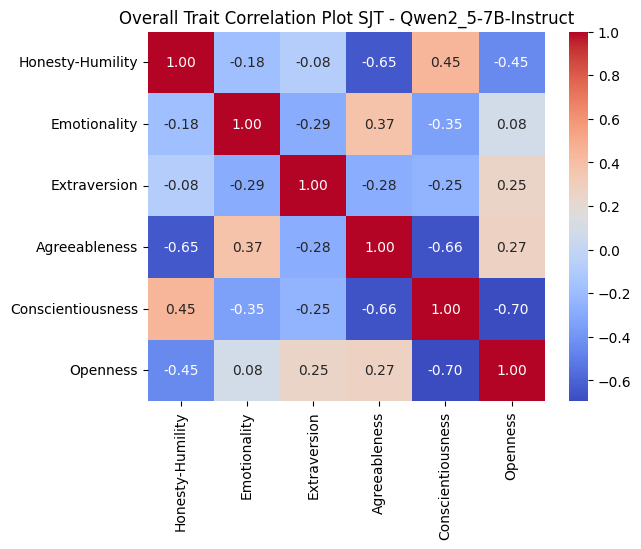

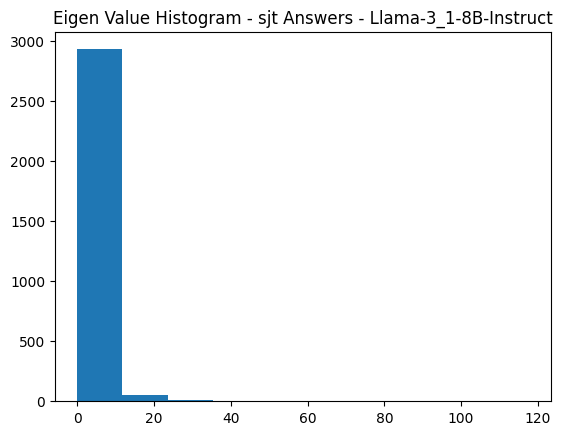

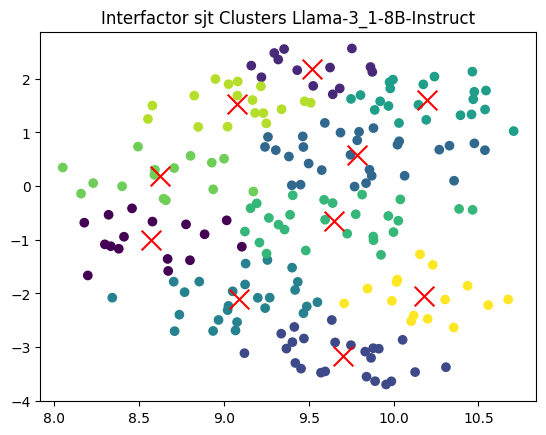

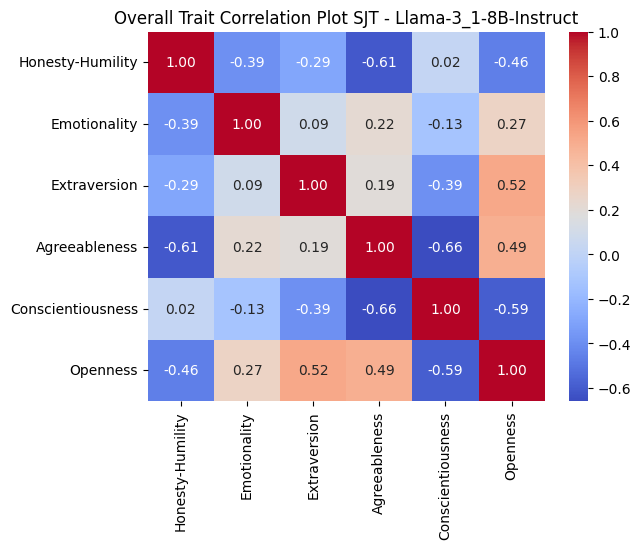

In [203]:
file_str = "huggingface"
# hf_sjt_trait_distributions_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_sjt_results = read_json(os.path.join(zero_compute_data_dir, filename))
        
        persona_sjt_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": get_true_indices(hf_persona_sjt_results[key])[0]} for key in hf_persona_sjt_results.keys()])
        # persona_sjt_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": get_trait_distribution(hf_persona_sjt_results[key])} for key in hf_persona_sjt_results.keys()])
        persona_sjt_str_answers_df = pd.DataFrame(persona_sjt_str_answers_df['answers'].to_list(), columns = list(range(0,500)), index = persona_sjt_str_answers_df['persona_id'])
        # persona_sjt_str_answers_df['model_name'] = model_name
        n_options = 6
        persona_sjt_answers_one_hot_df = pd.concat([
            pd.get_dummies(persona_sjt_str_answers_df[col], prefix=col).reindex(
                columns=[f"{col}_{i+1}" for i in range(n_options)],
                fill_value=0
            )
            for col in persona_sjt_str_answers_df.columns
        ], axis=1)

        persona_sjt_answers_one_hot_df = persona_sjt_answers_one_hot_df.astype(int)
        
        persona_sjt_answers_normalized_df = (persona_sjt_answers_one_hot_df - persona_sjt_answers_one_hot_df.mean()) / persona_sjt_answers_one_hot_df.std()
        persona_sjt_answers_normalized_df.fillna(0, inplace=True)
        
        plt.figure()
        plt.hist(np.linalg.eigvals(np.cov(persona_sjt_answers_normalized_df.values.T)))
        plt.title(f"Eigen Value Histogram - sjt Answers - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir,  "analysis_results",f"Eigen_histogram_sjt_{model_name}"), dpi=300)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_sjt_answers_normalized_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_
        
        plt.figure()
        plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o')
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
        plt.title(f"Interfactor sjt Clusters {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_sjt_{model_name}"), dpi=300)
        
        traits = sorted(set(col.split('_')[1] for col in persona_sjt_answers_normalized_df.columns))

        # Compute row-wise mean for each trait index
        trait_means = pd.DataFrame({
            f"trait_{trait}": persona_sjt_answers_normalized_df.filter(regex=fr"_{trait}$").mean(axis=1)
            for trait in traits
        })
        
        plt.figure()
        sns.heatmap(np.corrcoef(trait_means.T), annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=trait_map.values(),yticklabels=trait_map.values())
        plt.title(f"Overall Trait Correlation Plot SJT - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"trait_correlation_sjt_{model_name}"),
                    bbox_inches='tight', dpi=300)
        


sjt_trait_distributions = pd.DataFrame(hf_sjt_trait_distributions_df['answers'].to_list(), columns = trait_map.values(), index = hf_sjt_trait_distributions_df['persona_id']).reset_index()
sjt_trait_distributions['model_name'] = list(hf_sjt_trait_distributions_df['model_name'])

hf_hexaco_trait_persona_df = pd.read_csv("../experiment_results/zero_compute_analysis_hexaco/hf_hexaco_trait_persona_df.csv")

sjt_hexaco_combined_df = pd.concat([hf_hexaco_trait_persona_df, sjt_trait_distributions],axis = 1)

sjt_hexaco_combined_df.columns = ['hexaco_persona_id', 'honest-humility_hexaco_score', 'emotionality_hexaco_score', 'extraversion_hexaco_score',
       'agreeableness_hexaco_score', 'conscientiousness_hexaco_score', 'openness_to_experience_hexaco_score',
       'altruism', 'hexaco_model_name', 'sjt_persona_id', 'humility_sjt_dist',
       'emotionality_sjt_dist', 'extraversion_sjt_dist', 'agreeableness_sjt_dist', 'conscientiousness_sjt_dist',
       'openness_to_experience_sjt_dist', 'sjt_model_name']

sjt_hexaco_combined_df.to_csv(os.path.join(zero_compute_data_dir, "sjt_hexaco_combined_df.csv"), index = False)

In [201]:
persona_sjt_str_answers_df

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
persona_id,,,,,,,,,,,,,,,,,,,,,
782f13f4-0d98-41b4-a170-a2839dc6be70,4,3,1,4,1,6,1,2,4,4,...,1,4,6,5,4,5,6,4,1,6
81596279-9ae8-463f-bb93-f8f0f88d777e,4,6,1,5,1,6,5,1,4,5,...,1,3,5,5,5,5,4,1,4,6
6ce72d58-d03e-46d3-ae63-28b1bad56c26,4,6,1,1,5,6,1,5,6,4,...,6,3,5,5,4,5,4,1,6,1
e960e68a-f260-48df-8cb7-d6f8a46e470a,4,6,1,1,1,6,5,1,4,4,...,1,1,5,5,1,1,6,1,6,6
e3d265c4-b172-44f0-b058-be4d42fe5fb4,1,3,1,5,1,6,1,1,5,5,...,1,6,5,1,4,1,6,5,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197a10f3-35a9-4fda-8245-6a02c2980762,1,6,1,1,1,6,1,1,4,5,...,2,3,5,1,4,6,6,3,5,6
d1403dfc-c79b-4eb8-b017-372942ff3930,6,3,1,1,1,3,1,2,6,5,...,1,3,3,5,1,3,6,3,4,1
07406572-896a-42fe-bbc1-126104622bf7,1,6,1,4,1,6,1,1,4,5,...,2,3,3,5,5,6,4,3,4,1


In [206]:
login("")
persona_datasets = load_personas("thoughtworks/psychometric_personas",25)

Using Huggingface Personas
Loading Personas from thoughtworks/psychometric_personas
No of Personas: 200


In [207]:
archetype_df = persona_datasets[['uuid',"archetype"]].drop_duplicates()

huggingface_sjt_answers_gpt-4_1.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_sjt_answers_Qwen2_5-7B-Instruct.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_sjt_answers_Llama-3_1-8B-Instruct.json


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


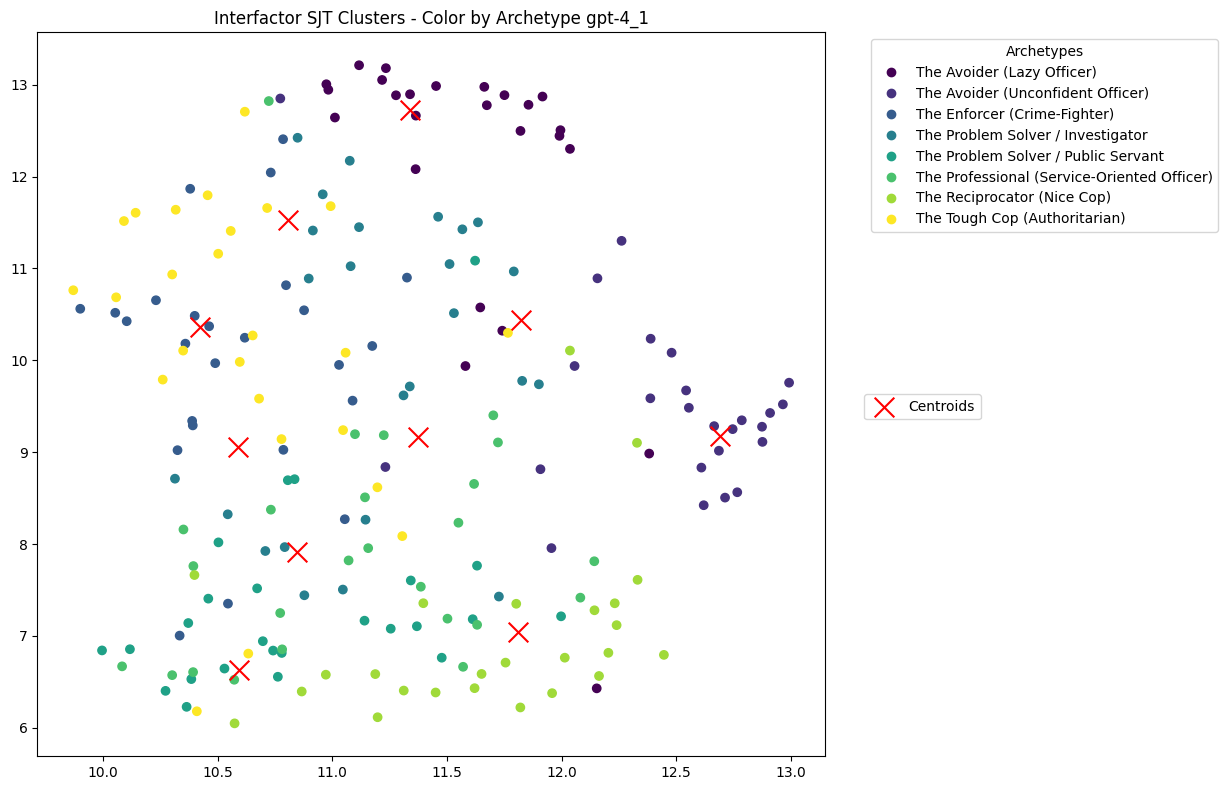

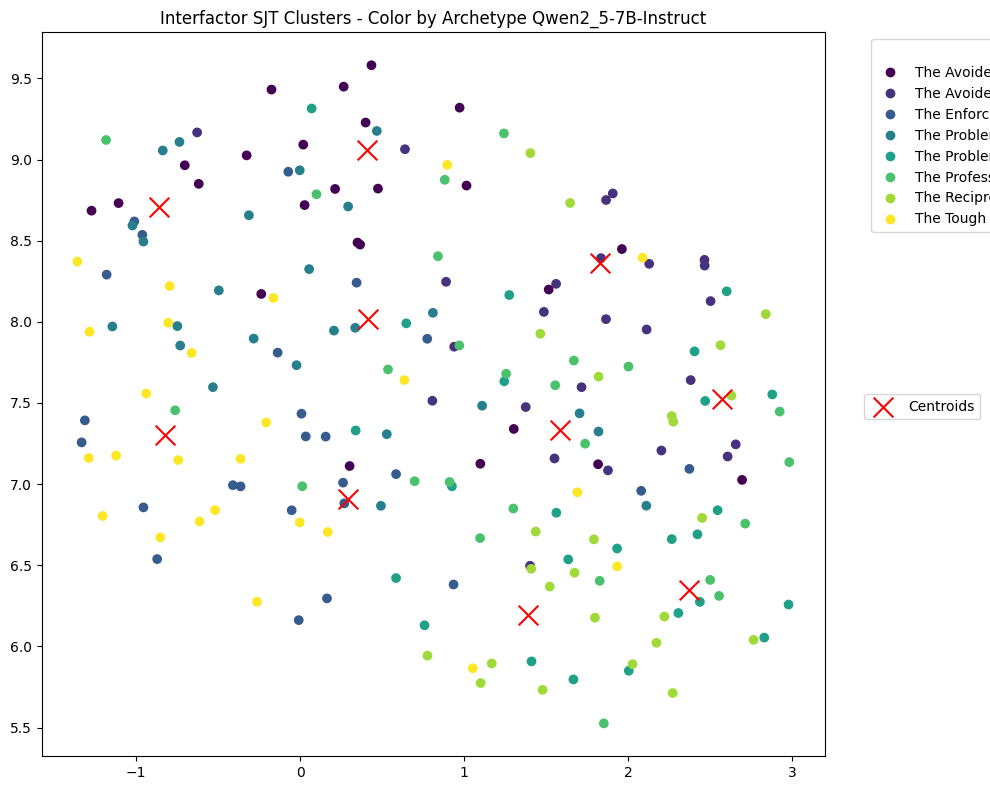

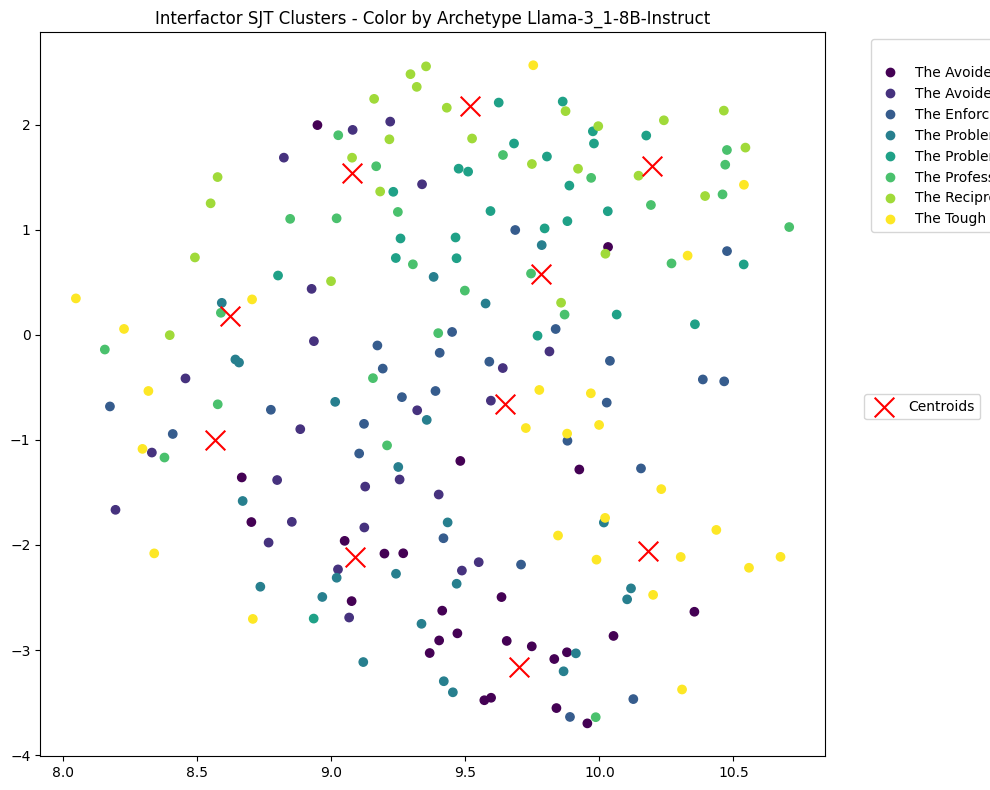

In [210]:
file_str = "huggingface"
# hf_sjt_trait_distributions_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_sjt_results = read_json(os.path.join(zero_compute_data_dir, filename))
        
        persona_sjt_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": get_true_indices(hf_persona_sjt_results[key])[0]} for key in hf_persona_sjt_results.keys()])
        # persona_sjt_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": get_trait_distribution(hf_persona_sjt_results[key])} for key in hf_persona_sjt_results.keys()])
        persona_sjt_str_answers_df = pd.DataFrame(persona_sjt_str_answers_df['answers'].to_list(), columns = list(range(0,500)), index = persona_sjt_str_answers_df['persona_id'])
        # persona_sjt_str_answers_df['model_name'] = model_name
        n_options = 6
        persona_sjt_answers_one_hot_df = pd.concat([
            pd.get_dummies(persona_sjt_str_answers_df[col], prefix=col).reindex(
                columns=[f"{col}_{i+1}" for i in range(n_options)],
                fill_value=0
            )
            for col in persona_sjt_str_answers_df.columns
        ], axis=1)

        persona_sjt_answers_one_hot_df = persona_sjt_answers_one_hot_df.astype(int)
        
        persona_sjt_answers_normalized_df = (persona_sjt_answers_one_hot_df - persona_sjt_answers_one_hot_df.mean()) / persona_sjt_answers_one_hot_df.std()
        persona_sjt_answers_normalized_df.fillna(0, inplace=True)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_sjt_answers_normalized_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_
        
        archetype_labels = pd.merge(archetype_df, pd.Series(persona_sjt_answers_normalized_df.index), left_on = "uuid", how='inner', right_on="persona_id")['archetype']
        archetype_codes = archetype_labels.astype('category').cat.codes
        
        plt.figure(figsize=(10, 8))
        ax = plt.gca()

        # Plot archetypes and capture the returned PathCollection object
        scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=archetype_codes, cmap='viridis', marker='o')

        # Plot centroids and capture the returned PathCollection object
        centroids_scatter = ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)

        # Set the title
        ax.set_title(f"Interfactor SJT Clusters - Color by Archetype {model_name}")

        # Get the original category labels for the archetype legend
        labels = archetype_labels.astype('category').cat.categories

        # Create the legend for the archetypes from the scatter plot elements
        handles, _ = scatter.legend_elements(prop='colors')
        legend1 = ax.legend(handles, labels, title='Archetypes', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Create the legend for the centroids manually
        # Use the handles from the centroids_scatter object
        legend2 = ax.legend([centroids_scatter], ['Centroids'], bbox_to_anchor=(1.05, 0.5), loc='upper left', borderaxespad=0.)

        # Add the first legend back to the axes, as the second call overrides it
        ax.add_artist(legend1)

        # Adjust layout to make room for the legend
        plt.tight_layout()
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_sjt_color_by_archetype{model_name}"), bbox_inches='tight', bbox_extra_artists=(legend1, legend2), dpi=300)


- make it one hot encoding (explore to 3000 columns)
- find the avg value of every column (1x5 row)
- normalize with mean values and divide by std
- then do PCA